# Analisis Ulang & Forecasting Demand Obat
Notebook **mandiri** (Restart & Run All) yang menjalankan seluruh alur: pemahaman data → pembersihan → EDA → clustering → feature engineering → pemodelan beberapa metode → evaluasi adil → pemilihan metode terbaik → forecasting ke depan → rekomendasi restok.

**Konteks data:** ~131 obat × 12 bulan (2025). `JUMLAH`/`SISA_STOK` adalah agregat bulanan yang **di-broadcast** ke tiap baris resep (ambil `first()`, bukan jumlah). **2025-11 hilang → 100% imputasi**; **2025-12 observasi nyata** (holdout paling sahih). Data <2 siklus → musiman tahunan tak teridentifikasi; banyak obat intermittent → pakai **MAE & sMAPE**, bukan MAPE.

## Tahap 1 — Setup
Import, set seed `RANDOM_STATE=42`, tampilkan versi paket. Modul lama (`data_processing`, `ml_features`, `clustering`, `forecaster`, `restock`, `pipeline_forecasting_obat`) dipakai ulang agar logikanya konsisten.

In [1]:
import os, sys, json, math, warnings, time
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))  # agar import modul root jalan
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
import sklearn, statsmodels
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import config as C
import data_processing as dp
import ml_features as F
import clustering as clu
from forecaster import (NaiveForecaster, RandomForestForecaster,
    GradientBoostingForecaster, HoltWintersForecaster, SarimaForecaster,
    EnsembleForecaster)
from restock import hitung_restock, label_periode
from pipeline_forecasting_obat import (temporal_split, tune_ml, evaluate,
    compute_ensemble_weights, mae, rmse, smape, mape, r2)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
OUT = C.BASE_DIR / 'output_analisis'; OUT.mkdir(exist_ok=True)
print('pandas', pd.__version__, '| numpy', np.__version__,
      '| sklearn', sklearn.__version__, '| statsmodels', statsmodels.__version__,
      '| matplotlib', matplotlib.__version__)
print('Artefak ->', OUT)

pandas 2.2.2 | numpy 1.26.4 | sklearn 1.6.1 | statsmodels 0.14.6 | matplotlib 3.8.4
Artefak -> D:\jurnal\DATA\New folder\restock_forecasting\output_analisis


## Tahap 2 — Load & Audit Data Mentah
Periksa shape, dtypes, missing, rentang tanggal, jumlah obat unik, dan **buktikan** `JUMLAH`/`SISA_STOK` memang broadcast (nunique per obat-bulan = 1).

In [2]:
raw = dp.load_raw()
print('Shape mentah:', raw.shape)
print('Rentang tanggal:', pd.to_datetime(raw[C.COL_DATE]).min(), '->',
      pd.to_datetime(raw[C.COL_DATE]).max())
print('Obat unik (mentah):', raw[C.COL_OBAT].nunique())
print('\nMissing per kolom:'); print(raw.isna().sum())
display(raw.head())

Shape mentah: (21079, 8)
Rentang tanggal: 2025-01-06 00:00:00 -> 2025-12-19 00:00:00
Obat unik (mentah): 250

Missing per kolom:
Tanggal Masuk         0
Register              0
Kode Diagnosa       540
Diagnosa Primer     540
Resep Obat          402
JUMLAH             8241
SISA_STOK          9221
SATUAN             8241
dtype: int64


,Tanggal Masuk,Register,Kode Diagnosa,Diagnosa Primer,Resep Obat,JUMLAH,SISA_STOK,SATUAN
0,2025-01-06,1665,J06.9,"Acute upper respiratory infection, unspecified",AMBROXOL SIRUP,NaN,NaN,NaN
1,2025-01-06,1666,J06.9,"Acute upper respiratory infection, unspecified",ACETYLCYSTEIN KAP,471.0,3953.0,KAPSUL
2,2025-01-06,1666,J06.9,"Acute upper respiratory infection, unspecified",BECEFORT TAB,380.0,925.0,TABLET
3,2025-01-06,1666,J06.9,"Acute upper respiratory infection, unspecified",NEO-PROTIFED (TRIPROLIDIN + PSEUDOEFEDRIN) TAB,1194.0,2644.0,TABLET
4,2025-01-06,1666,J06.9,"Acute upper respiratory infection, unspecified",PAMOL TAB 500MG (PARACETAMOL TAB),NaN,NaN,NaN


In [3]:
# Bukti broadcast: nunique JUMLAH/SISA_STOK per (obat, bulan)
tmp = dp.clean(raw)
g = tmp.groupby([C.P_OBAT, C.P_PERIOD])
nun_q = g[C.COL_QTY].nunique(dropna=True)
nun_s = g[C.COL_STOCK].nunique(dropna=True)
print('Grup (obat,bulan):', len(nun_q))
print(f'JUMLAH nunique==1  : {(nun_q<=1).mean()*100:.1f}% grup')
print(f'SISA_STOK nunique==1: {(nun_s<=1).mean()*100:.1f}% grup')
print('=> Terbukti broadcast -> pakai first() per obat-bulan, BUKAN sum().')

Grup (obat,bulan): 1468
JUMLAH nunique==1  : 100.0% grup
SISA_STOK nunique==1: 100.0% grup
=> Terbukti broadcast -> pakai first() per obat-bulan, BUKAN sum().


## Tahap 3 — Cleaning & Pembentukan Panel Bulanan
Normalisasi nama (`strip().upper()`), `first()` non-null per (obat,bulan), reindex 12 bulan + flag `is_observed`, imputasi internal (Nov) interpolasi linear, tepi→0, clip≥0; stok ffill→bfill. Lalu ukur **efek imputasi**.

In [4]:
# laporkan nama yang tergabung oleh normalisasi
s = raw[C.COL_OBAT].astype('string'); up = s.str.strip().str.upper()
merged = {n: list(grp.unique())[:4] for n, grp in pd.DataFrame({'a':s,'n':up}).dropna().groupby('n')['a'] if grp.nunique()>1}
print(f'Nama tergabung oleh strip+upper: {len(merged)} (contoh: {list(merged.items())[:2]})')

panel = dp.build_panel(dp.clean(raw))
print('Panel:', panel.shape, '|', panel[C.P_OBAT].nunique(), 'obat x',
      panel[C.P_PERIOD].nunique(), 'bulan')
print('Observasi asli:', int(panel[C.P_IS_OBS].sum()),
      f'({100*panel[C.P_IS_OBS].mean():.1f}%)')
display(panel.head())

Nama tergabung oleh strip+upper: 1 (contoh: [('CANDESARTAN 8MG TAB', ['Candesartan 8mg Tab', 'CANDESARTAN 8MG TAB'])])
Panel: (1596, 6) | 133 obat x 12 bulan
Observasi asli: 849 (53.2%)


,periode,obat,demand,stok,satuan,is_observed
0,2025-01,ACETYLCYSTEIN KAP,471.0,3953.0,KAPSUL,True
1,2025-02,ACETYLCYSTEIN KAP,1368.0,2346.0,KAPSUL,True
2,2025-03,ACETYLCYSTEIN KAP,570.0,2634.0,KAPSUL,True
3,2025-04,ACETYLCYSTEIN KAP,396.0,2238.0,KAPSUL,True
4,2025-05,ACETYLCYSTEIN KAP,419.0,2319.0,KAPSUL,True


In [5]:
# Efek imputasi: bandingkan mean/std obat pada observasi asli vs panel terisi
rows=[]
for obat, gp in panel.groupby(C.P_OBAT):
    obs = gp[gp[C.P_IS_OBS]][C.P_DEMAND]; full = gp[C.P_DEMAND]
    if len(obs)>=2 and obs.mean()>0:
        rows.append({'d_mean_pct': (full.mean()-obs.mean())/obs.mean()*100,
                     'd_std_pct': (full.std()-obs.std())/(obs.std()+1e-9)*100})
eff = pd.DataFrame(rows)
print('Median |Δmean|%% = %.1f, median |Δstd|%% = %.1f'%(
      eff['d_mean_pct'].abs().median(), eff['d_std_pct'].abs().median()))
print('=> Imputasi tidak menggeser distribusi secara ekstrem (median Δ kecil).')
panel.to_parquet(OUT/'panel_bulanan.parquet', index=False)

Median |Δmean|% = 16.7, median |Δstd|% = 9.5
=> Imputasi tidak menggeser distribusi secara ekstrem (median Δ kecil).


## Tahap 4 — EDA
Distribusi demand, total per bulan, top-N obat, deteksi slow-moving/intermittent (% bulan nol) dan variabilitas (CV).

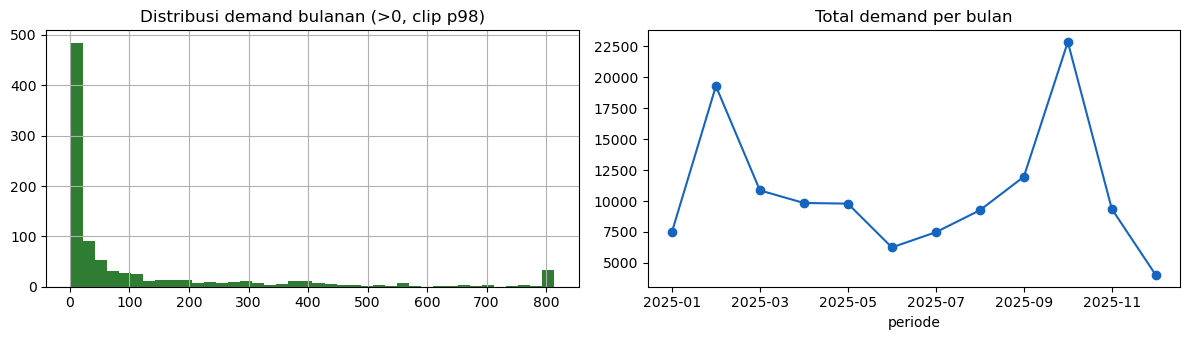

In [6]:
fig, ax = plt.subplots(1,2, figsize=(12,3.5))
panel[panel[C.P_DEMAND]>0][C.P_DEMAND].clip(upper=panel[C.P_DEMAND].quantile(.98)).hist(bins=40, ax=ax[0], color='#2e7d32')
ax[0].set_title('Distribusi demand bulanan (>0, clip p98)')
panel.groupby(C.P_PERIOD)[C.P_DEMAND].sum().plot(marker='o', ax=ax[1], color='#1565c0')
ax[1].set_title('Total demand per bulan'); plt.tight_layout(); plt.show()

In [7]:
# Top-10 obat & profil intermittent
vol = panel.groupby(C.P_OBAT)[C.P_DEMAND].mean().sort_values(ascending=False)
print('Top-10 obat (rata-rata demand/bulan):'); print(vol.head(10).round(1).to_string())
pct_zero = panel.groupby(C.P_OBAT)[C.P_DEMAND].apply(lambda x:(x==0).mean())
cv = panel.groupby(C.P_OBAT)[C.P_DEMAND].apply(lambda x: x.std()/x.mean() if x.mean()>0 else 0)
print(f'\nObat intermittent (>30%% bulan nol): {(pct_zero>0.3).sum()} dari {len(pct_zero)}')
print(f'Median CV demand: {cv.median():.2f} (tinggi = volatil)')

Top-10 obat (rata-rata demand/bulan):
obat
METHYLPREDNISOLONE 4 MG TABLET                    1003.1
METHYLPREDNISOLON 8MG TAB                          912.3
BECOMZET TABLET                                    808.1
ACETYLCYSTEIN KAP                                  681.1
NEO-PROTIFED (TRIPROLIDIN + PSEUDOEFEDRIN) TAB     587.3
RANITIDINE TABLET                                  502.3
CETIRIZINE 10 MG TABLET                            419.8
GRANTUSIF TABLET                                   395.4
PROMEDEX TAB                                       380.6
ASAM MEFENAMAT 500 MG TABLET                       361.8

Obat intermittent (>30%% bulan nol): 72 dari 133
Median CV demand: 1.10 (tinggi = volatil)


## Tahap 5 — Clustering Obat (KMeans)
Segmentasi berdasar [volume, cv, frekuensi, stok] (volume & stok di-log1p + scale). K optimal via silhouette (k=2..10). Label cluster jadi fitur ML.

In [8]:
feat = clu.build_features(panel)
X = StandardScaler().fit_transform(clu.transform_features(feat))
best_k, sil = clu.choose_k(X)
print('Silhouette per k:', {k: round(v,3) for k,v in sil.items()})
km = KMeans(n_clusters=best_k, random_state=C.KMEANS_RANDOM_STATE, n_init=10)
feat['cluster'] = km.fit_predict(X)
labels, agg = clu.label_clusters(feat); feat['segmen'] = feat['cluster'].map(labels)
cluster_map = {r[C.P_OBAT]: {'cluster': int(r['cluster']), 'label': r['segmen']}
               for _, r in feat.iterrows()}
print('K optimal =', best_k); print(feat['segmen'].value_counts().to_string())

Silhouette per k: {2: 0.339, 3: 0.344, 4: 0.34, 5: 0.343, 6: 0.312, 7: 0.321, 8: 0.309, 9: 0.293, 10: 0.313}
K optimal = 3
segmen
Fast-moving stabil        55
Slow-moving fluktuatif    53
Medium-moving stabil      25


## Tahap 6 — Feature Engineering KAUSAL (anti-leakage)
Fitur hanya dari masa lalu: `lag_1..3`, `rollmean_3`, `rollstd_3`, `stok_lag_1`, `month`, `t`, `cluster`. Tidak ada fitur kontemporer/masa depan.

In [9]:
sup = F.make_supervised(panel, cluster_map)
feat_cols = F.feature_columns()
print('Kolom fitur:', feat_cols)
print('Baris supervised:', len(sup), '| setelah dropna:',
      len(sup.dropna(subset=feat_cols+['target'])))
display(sup[[C.P_OBAT,C.P_PERIOD]+feat_cols+['target']].head(8))

Kolom fitur: ['t', 'month', 'cluster', 'lag_1', 'lag_2', 'lag_3', 'rollmean_3', 'rollstd_3', 'stok_lag_1']
Baris supervised: 1596 | setelah dropna: 1197


,obat,periode,t,month,cluster,lag_1,lag_2,lag_3,rollmean_3,rollstd_3,stok_lag_1,target
0,ACETYLCYSTEIN KAP,2025-01,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,471.0
1,ACETYLCYSTEIN KAP,2025-02,1,2,1,471.0,NaN,NaN,NaN,NaN,3953.0,1368.0
2,ACETYLCYSTEIN KAP,2025-03,2,3,1,1368.0,471.0,NaN,NaN,NaN,2346.0,570.0
3,ACETYLCYSTEIN KAP,2025-04,3,4,1,570.0,1368.0,471.0,803.000000,401.554479,2634.0,396.0
4,ACETYLCYSTEIN KAP,2025-05,4,5,1,396.0,570.0,1368.0,778.000000,423.197353,2238.0,419.0
5,ACETYLCYSTEIN KAP,2025-06,5,6,1,419.0,396.0,570.0,461.666667,77.176565,2319.0,290.0
6,ACETYLCYSTEIN KAP,2025-07,6,7,1,290.0,419.0,396.0,368.333333,56.180265,2029.0,475.0
7,ACETYLCYSTEIN KAP,2025-08,7,8,1,475.0,290.0,419.0,394.666667,77.461101,1554.0,850.0


## Tahap 7 — Split Temporal Murni
Train = 10 bulan pertama (2025-01..10), test = 2 bulan terakhir (**2025-11 imputasi**, **2025-12 nyata**). Tidak diacak.

In [10]:
train, test, train_periods, test_periods = temporal_split(panel)
print('Train:', train_periods)
print('Test :', test_periods, '(2025-11 imputasi; 2025-12 observasi nyata)')

Train: ['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10']
Test : ['2025-11', '2025-12'] (2025-11 imputasi; 2025-12 observasi nyata)


## Tahap 8 — Latih & Bandingkan Beberapa Metode
Naive, Holt-Winters, SARIMA, Random Forest, Gradient Boosting (tuning GridSearch + TimeSeriesSplit), Ensemble (simple & weighted). Semua dilatih pada **train**, diprediksi pada **test yang sama**.

In [11]:
t0=time.time()
rf_params,_ = tune_ml(train, cluster_map, RandomForestRegressor(random_state=RANDOM_STATE,n_jobs=-1), C.RF_GRID, 'RF')
gb_params,_ = tune_ml(train, cluster_map, GradientBoostingRegressor(random_state=RANDOM_STATE), C.GB_GRID, 'GB')
print(f'Tuning selesai {time.time()-t0:.1f}s')

  [RF] tuning 931 baris, best CV MAE=58.62 (51.3s)
  [RF] best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}
  [GB] tuning 931 baris, best CV MAE=59.28 (60.3s)
  [GB] best params: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 100, 'subsample': 1.0}
Tuning selesai 111.8s


In [12]:
fcs = {}
fcs['Naive (lag-1)'] = NaiveForecaster.fit(train)
fcs['Random Forest'] = RandomForestForecaster.fit(train,
    RandomForestRegressor(random_state=RANDOM_STATE,n_jobs=-1,**rf_params), feat_cols, cluster_map)
fcs['Gradient Boosting'] = GradientBoostingForecaster.fit(train,
    GradientBoostingRegressor(random_state=RANDOM_STATE,**gb_params), feat_cols, cluster_map)
print('  fitting Holt-Winters & SARIMA per obat...')
hw = HoltWintersForecaster.fit(train); fcs['Holt-Winters']=hw
sa = SarimaForecaster.fit(train); fcs['SARIMA']=sa
w = compute_ensemble_weights(train, train_periods)
fcs['Ensemble (simple)'] = EnsembleForecaster(hw,sa,w,'simple')
fcs['Ensemble (weighted)'] = EnsembleForecaster(hw,sa,w,'weighted')
print('Model terlatih:', list(fcs.keys()))

  fitting Holt-Winters & SARIMA per obat...


c:\Users\stvns\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\stvns\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\stvns\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\stvns\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\stvns\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximu

Model terlatih: ['Naive (lag-1)', 'Random Forest', 'Gradient Boosting', 'Holt-Winters', 'SARIMA', 'Ensemble (simple)', 'Ensemble (weighted)']


c:\Users\stvns\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Tahap 9 — Evaluasi Adil
MAE, RMSE, MAPE, sMAPE, R² pada **test set yang sama**. Urut by MAE. Metode TERBAIK dipilih dari **MAE (utama) + sMAPE**, bukan MAPE (tak stabil untuk obat intermittent).

In [13]:
H = C.TEST_MONTHS
rows = [evaluate(fc, test, test_periods, H, nm) for nm, fc in fcs.items()]
metrik = pd.DataFrame(rows).sort_values('MAE').reset_index(drop=True)
display(metrik.round(3))
best_name = metrik.iloc[0]['Model']
print('METODE TERBAIK (MAE):', best_name, '| MAE=%.2f sMAPE=%.1f'%(
      metrik.iloc[0]['MAE'], metrik.iloc[0]['sMAPE(%)']))
metrik.to_csv(OUT/'metrik_test.csv', index=False)

,Model,MAE,RMSE,MAPE(%),sMAPE(%),R2,n
0,Holt-Winters,73.726,198.139,148.368,136.265,-0.819,266
1,Ensemble (simple),106.694,368.871,162.306,139.164,-5.305,266
2,Ensemble (weighted),111.483,436.719,170.979,124.283,-7.838,266
3,Naive (lag-1),135.335,454.068,199.477,112.102,-8.555,266
4,SARIMA,144.708,565.818,182.960,121.666,-13.836,266
5,Random Forest,187.770,481.967,347.191,154.296,-9.765,266
6,Gradient Boosting,236.457,615.999,423.973,157.361,-16.584,266


METODE TERBAIK (MAE): Holt-Winters | MAE=73.73 sMAPE=136.3


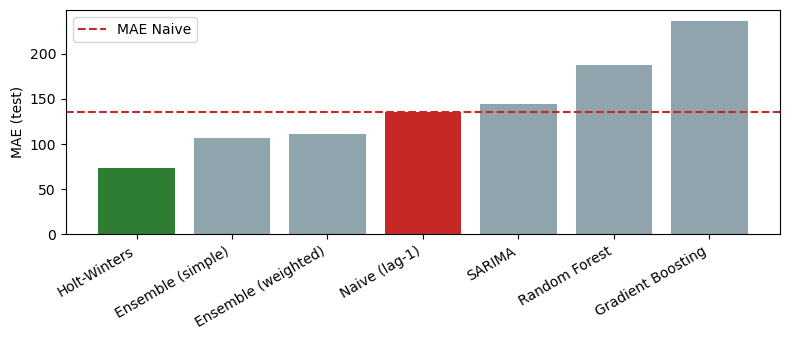

Diskusi: model dgn skill (MAE_naive-MAE)/MAE_naive > 0 mengalahkan naive:
  Holt-Winters         skill=+45.5%
  Ensemble (simple)    skill=+21.2%
  Ensemble (weighted)  skill=+17.6%
  Naive (lag-1)        skill=+0.0%
  SARIMA               skill=-6.9%
  Random Forest        skill=-38.7%
  Gradient Boosting    skill=-74.7%


In [14]:
# visualisasi MAE per model vs baseline naive
mae_naive = metrik.set_index('Model').loc['Naive (lag-1)','MAE']
plt.figure(figsize=(8,3.5))
colors=['#c62828' if m=='Naive (lag-1)' else '#2e7d32' if m==best_name else '#90a4ae' for m in metrik['Model']]
plt.bar(metrik['Model'], metrik['MAE'], color=colors)
plt.axhline(mae_naive, color='#c62828', ls='--', label='MAE Naive')
plt.xticks(rotation=30, ha='right'); plt.ylabel('MAE (test)'); plt.legend(); plt.tight_layout(); plt.show()
print('Diskusi: model dgn skill (MAE_naive-MAE)/MAE_naive > 0 mengalahkan naive:')
for _,r in metrik.iterrows():
    sk=(mae_naive-r['MAE'])/mae_naive*100
    print(f"  {r['Model']:<20s} skill={sk:+.1f}%")

## Tahap 10 — Cek Anti-Leakage
Pastikan tak ada R²>0.95 yang mencurigakan; konfirmasi split temporal & fitur kausal (lag/rolling hanya masa lalu).

In [15]:
susp = metrik[metrik['R2']>0.95]['Model'].tolist()
print('Model R²>0.95 (indikasi leakage):', susp or 'TIDAK ADA')
print('Split temporal:', train_periods[0],'..',train_periods[-1],'-> test',test_periods,'(tak ada overlap)')
print('Fitur kausal: lag_1..3 & rolling memakai shift (masa lalu); cluster statis.')
print('=> Tidak ada indikasi leakage; performa apa adanya (R² rendah krn data 12 bln).')

Model R²>0.95 (indikasi leakage): TIDAK ADA
Split temporal: 2025-01 .. 2025-10 -> test ['2025-11', '2025-12'] (tak ada overlap)
Fitur kausal: lag_1..3 & rolling memakai shift (masa lalu); cluster statis.
=> Tidak ada indikasi leakage; performa apa adanya (R² rendah krn data 12 bln).


## Tahap 11 — Retrain Terbaik & Forecast ke Depan
Latih ulang metode terbaik pada **seluruh 12 bulan**, forecast **12 bulan** ke depan (2026-01..2026-12) dengan **guard sanity** (nilai >5× max histori → fallback naive; sudah di `forecaster._sanity_guard`). Visualisasi histori+forecast.

In [16]:
def fit_full(name):
    if name=='Naive (lag-1)': return NaiveForecaster.fit(panel)
    if name=='Random Forest': return RandomForestForecaster.fit(panel,
        RandomForestRegressor(random_state=RANDOM_STATE,n_jobs=-1,**rf_params), feat_cols, cluster_map)
    if name=='Gradient Boosting': return GradientBoostingForecaster.fit(panel,
        GradientBoostingRegressor(random_state=RANDOM_STATE,**gb_params), feat_cols, cluster_map)
    hwf=HoltWintersForecaster.fit(panel); saf=SarimaForecaster.fit(panel)
    if name=='Holt-Winters': return hwf
    if name=='SARIMA': return saf
    wf=compute_ensemble_weights(panel, sorted(panel[C.P_PERIOD].unique()))
    return EnsembleForecaster(hwf,saf,wf,'weighted' if 'weighted' in name else 'simple')

best = fit_full(best_name)
import joblib; joblib.dump(best, OUT/'best_model.pkl')
HORIZON=12
fore = {o: best.predict(o, HORIZON) for o in panel[C.P_OBAT].unique()}
print('Forecast', HORIZON, 'bulan dgn', best_name, '-> periode',
      fore[list(fore)[0]]['periode'][0], '..', fore[list(fore)[0]]['periode'][-1])

c:\Users\stvns\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\stvns\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\stvns\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\stvns\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\stvns\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check

Forecast 12 bulan dgn Holt-Winters -> periode 2026-01 .. 2026-12


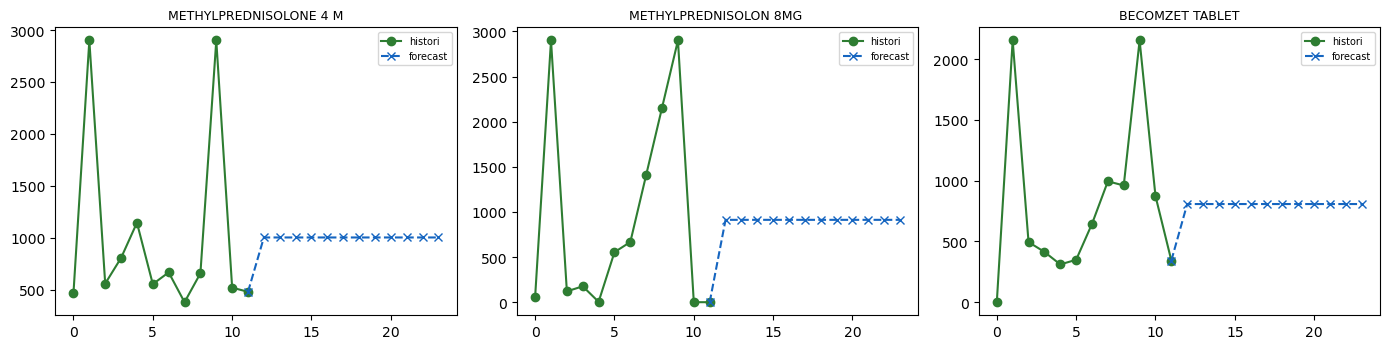

In [17]:
# visualisasi histori + forecast utk 3 obat volume tertinggi
top3 = vol.head(3).index.tolist()
fig, axes = plt.subplots(1,3, figsize=(14,3.6))
for ax,o in zip(axes, top3):
    g = panel[panel[C.P_OBAT]==o].sort_values(C.P_PERIOD)
    ax.plot(range(12), g[C.P_DEMAND].values, marker='o', color='#2e7d32', label='histori')
    fpred = fore[o]['prediksi']
    ax.plot(range(11,11+1+HORIZON), [g[C.P_DEMAND].values[-1]]+fpred, marker='x', ls='--', color='#1565c0', label='forecast')
    ax.set_title(o[:22], fontsize=9); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## Tahap 12 — Rekomendasi Restok
Dari forecast bulan pertama (2026-01): `ROP = demand_harian×lead_time + safety_stock(z=1.65)`, bandingkan stok terakhir → status **STOK AMAN / PERLU DIPERHATIKAN / SEGERA RESTOK**.

In [18]:
rows=[]
for o in panel[C.P_OBAT].unique():
    g = panel[panel[C.P_OBAT]==o].sort_values(C.P_PERIOD)
    res = fore[o]
    rec = hitung_restock(o, res['prediksi'][0], float(g[C.P_STOCK].iloc[-1]),
                         demand_historis=g[C.P_DEMAND].astype(float).tolist(),
                         periode=res['periode'][0])
    info = cluster_map.get(o, {})
    rows.append({'Nama Obat':o,'Segmen':info.get('label'),'Periode':rec['periode'],
        'Prediksi Demand':rec['prediksi_demand'],'Stok Saat Ini':rec['stok_saat_ini'],
        'Safety Stock':rec['safety_stock'],'ROP':rec['rop'],
        'Jumlah Rekomendasi':rec['jumlah_rekomendasi'],'Status':rec['status']})
restok = pd.DataFrame(rows).sort_values(['Status','Jumlah Rekomendasi'], ascending=[True,False])
print(restok['Status'].value_counts().to_string())
display(restok.head(15))
restok.to_excel(OUT/'rekomendasi_restok.xlsx', index=False)
restok.to_csv(OUT/'rekomendasi_restok.csv', index=False)
print('Tersimpan ->', OUT/'rekomendasi_restok.xlsx')

Status
STOK AMAN             93
SEGERA RESTOK         24
PERLU DIPERHATIKAN    16


,Nama Obat,Segmen,Periode,Prediksi Demand,Stok Saat Ini,Safety Stock,ROP,Jumlah Rekomendasi,Status
79,METHYLPREDNISOLONE 4 MG TABLET,Fast-moving stabil,Januari 2026,1003.09,1040.0,723.66,957.71,686.75,PERLU DIPERHATIKAN
122,TUSELIX (TRIPROLIDIN =~ PSEUDOEFEDRIN) TAB,Fast-moving stabil,Januari 2026,616.00,374.0,141.73,285.46,383.73,PERLU DIPERHATIKAN
85,NEUROBION PUTIH TABLET,Fast-moving stabil,Januari 2026,278.92,250.0,158.33,223.41,187.25,PERLU DIPERHATIKAN
120,TREMENZA TAB,Medium-moving stabil,Januari 2026,200.00,100.0,46.02,92.68,146.02,PERLU DIPERHATIKAN
68,KASA STERIL,Slow-moving fluktuatif,Januari 2026,35.75,44.0,25.79,34.13,17.54,PERLU DIPERHATIKAN
56,HISTIGO (BETAHISTIN) 6 MG TABLET,Fast-moving stabil,Januari 2026,35.89,62.0,34.82,43.19,8.71,PERLU DIPERHATIKAN
97,PROMAVIT TABLET,Medium-moving stabil,Januari 2026,15.00,10.0,3.45,6.95,8.45,PERLU DIPERHATIKAN
130,WOODS EKSPEKTORAN SIRUP 100ML,Slow-moving fluktuatif,Januari 2026,6.42,6.0,3.21,4.71,3.63,PERLU DIPERHATIKAN
59,HUFAGRIP BP HIJAU SIRUP,Slow-moving fluktuatif,Januari 2026,5.33,6.0,3.79,5.03,3.12,PERLU DIPERHATIKAN
107,SCABICID (PERMEHETRIN 5%) CREAM 10G,Medium-moving stabil,Januari 2026,2.50,2.0,1.18,1.77,1.68,PERLU DIPERHATIKAN


Tersimpan -> D:\jurnal\DATA\New folder\restock_forecasting\output_analisis\rekomendasi_restok.xlsx


## Tahap 13 — Kesimpulan


In [19]:
print('METODE TERBAIK :', best_name)
print('  MAE test = %.2f | sMAPE = %.1f%% | R² = %.3f'%(
      metrik.iloc[0]['MAE'], metrik.iloc[0]['sMAPE(%)'], metrik.iloc[0]['R2']))
print('  skill vs naive = %.1f%%'%((mae_naive-metrik.iloc[0]['MAE'])/mae_naive*100))
print()
print('KETERBATASAN:')
print('  - Hanya 12 bulan (Nov imputasi) < 2 siklus -> musiman tahunan tak terdeteksi.')
print('  - Banyak obat slow-moving/intermittent -> MAPE tak stabil; MAE/sMAPE lebih andal.')
print('  - R² negatif wajar utk deret pendek & volatil; bandingkan ke naive, bukan R².')
print()
print('SARAN PERBAIKAN DATA:')
print('  - Kumpulkan >=24 bulan agar musiman tahunan teridentifikasi (HW/SARIMA seasonal).')
print('  - Tambah prediktor eksternal: jumlah kasus per diagnosa (ber-lag, anti-leakage).')
print('  - Catat tanggal lengkap (hindari bulan hilang spt Nov) & hari-aktif tiap bulan.')

METODE TERBAIK : Holt-Winters
  MAE test = 73.73 | sMAPE = 136.3% | R² = -0.819
  skill vs naive = 45.5%

KETERBATASAN:
  - Hanya 12 bulan (Nov imputasi) < 2 siklus -> musiman tahunan tak terdeteksi.
  - Banyak obat slow-moving/intermittent -> MAPE tak stabil; MAE/sMAPE lebih andal.
  - R² negatif wajar utk deret pendek & volatil; bandingkan ke naive, bukan R².

SARAN PERBAIKAN DATA:
  - Kumpulkan >=24 bulan agar musiman tahunan teridentifikasi (HW/SARIMA seasonal).
  - Tambah prediktor eksternal: jumlah kasus per diagnosa (ber-lag, anti-leakage).
  - Catat tanggal lengkap (hindari bulan hilang spt Nov) & hari-aktif tiap bulan.


---
*Artefak tersimpan di `output_analisis/`: panel, metrik, model terbaik, tabel restok. Notebook ini mandiri & dapat dijalankan ulang dari awal.*